# Experiment: Grid-aligned Fgen comparison

Compare native-grid Fgen with the grid-aligned methods from `comparason_test.py`, including the notebook-style xESMF `regridder` method. The notebook now defaults to the all-model result pickle and keeps track of methods that failed for individual models.


## Generate comparison data

Run this from the repository root before evaluating the notebook. This command writes the all-model result file used below:

```bash
python scripts/GridAlignment/comparason_test.py   --models ACCESS-CM2 ACCESS-ESM1-5 CAS-ESM2-0 CanESM5 CanESM5-1 E3SM-1-0 FGOALS-f3-L FGOALS-g3 GISS-E2-1-G-CC GISS-E2-2-G ICON-ESM-LR MIROC6 MPI-ESM-1-2-HAM MPI-ESM1-2-HR MPI-ESM1-2-LR MRI-ESM2-0 NorESM2-LM NorESM2-MM SAM0-UNICON   --methods original nearest binned regridder   --last-n-months 12   --resolution 2   --output /glade/derecho/scratch/stevenxu/tmp/gridtest_Fgen_allmodels.pkl
```

If the run is interrupted, use the same command with `--resume`. The driver computes nonlinear diagnostics on the native grid first; only the completed diagnostics are regridded for the aligned methods.


In [1]:
from pathlib import Path
import pickle

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

RESULT_CANDIDATES = [
    Path('/glade/derecho/scratch/stevenxu/tmp/gridtest_Fgen_allmodels.pkl'),
    Path('/glade/derecho/scratch/stevenxu/tmp/gridtest_Fgen.pkl'),
]
RESULT_PATH = next((path for path in RESULT_CANDIDATES if path.exists()), RESULT_CANDIDATES[0])
RHO_PLOT_MIN = 1020.0
METHOD_ORDER = ('original', 'nearest', 'binned', 'regridder')
METHOD_STYLES = {
    'original': {'color': 'black', 'linestyle': '-', 'linewidth': 2.2},
    'nearest': {'color': 'tab:orange', 'linestyle': '--', 'linewidth': 1.8},
    'binned': {'color': 'tab:blue', 'linestyle': '-.', 'linewidth': 1.8},
    'regridder': {'color': 'tab:green', 'linestyle': ':', 'linewidth': 2.2},
}

if not RESULT_PATH.exists():
    raise FileNotFoundError(f'Run comparason_test.py first; missing {RESULT_PATH}')


In [2]:
with RESULT_PATH.open('rb') as handle:
    payload = pickle.load(handle)

metadata = payload['metadata']
results = payload['results']
methods = [method for method in METHOD_ORDER if method in results and results[method]]
all_models = sorted(set().union(*(set(results[method]) for method in methods))) if methods else []
model_sets = [set(results[method]) for method in methods]
common_models = sorted(set.intersection(*model_sets)) if model_sets else []
errors = pd.DataFrame(payload.get('errors', []))
timings = pd.DataFrame(payload.get('timings', []))

completed = pd.DataFrame(False, index=all_models, columns=methods)
for method in methods:
    completed.loc[sorted(results[method]), method] = True
method_counts = completed.sum().rename('completed_models').to_frame()
method_counts['requested_models'] = len(all_models)
method_counts['completion_fraction'] = method_counts['completed_models'] / method_counts['requested_models']

metadata_view = pd.Series(metadata, name='value').to_frame()
print('Result file:', RESULT_PATH)
print('Models with any result:', len(all_models))
print('Models completed by every available method:', len(common_models))
print('Available methods:', methods)
display(metadata_view)
display(method_counts)
display(completed.replace({True: 'yes', False: ''}))
display(errors if not errors.empty else pd.DataFrame({'status': ['No recorded errors']}))


Result file: /glade/derecho/scratch/stevenxu/tmp/gridtest_Fgen_allmodels.pkl
Models with any result: 19
Models completed by every available method: 17
Available methods: ['original', 'nearest', 'binned', 'regridder']


,value
created_utc,2026-07-01T07:09:58.188244+00:00
scenario,PIControl
models_requested,"[ACCESS-CM2, ACCESS-ESM1-5, CAS-ESM2-0, CanESM..."
methods_requested,"[original, nearest, binned, regridder]"
resolution_degrees,2.0
last_n_years,2
last_n_months,12
rho_min,1015.0
rho_max,1030.0
step_size,0.05


,completed_models,requested_models,completion_fraction
original,19,19,1.000000
nearest,17,19,0.894737
binned,17,19,0.894737
regridder,19,19,1.000000


,original,nearest,binned,regridder
ACCESS-CM2,yes,yes,yes,yes
ACCESS-ESM1-5,yes,yes,yes,yes
CAS-ESM2-0,yes,yes,yes,yes
CanESM5,yes,yes,yes,yes
CanESM5-1,yes,yes,yes,yes
E3SM-1-0,yes,yes,yes,yes
FGOALS-f3-L,yes,,,yes
FGOALS-g3,yes,,,yes
GISS-E2-1-G-CC,yes,yes,yes,yes
GISS-E2-2-G,yes,yes,yes,yes


,model,method,stage,error
0,FGOALS-f3-L,nearest,method,ValueError('Area latitude/longitude do not mat...
1,FGOALS-f3-L,binned,method,ValueError('Area latitude/longitude do not mat...
2,FGOALS-g3,nearest,method,ValueError('Area latitude/longitude do not mat...
3,FGOALS-g3,binned,method,ValueError('Area latitude/longitude do not mat...


## Fgen density profiles

The profile plots overlay each available method against density class. The first profile figure uses only the models that completed every method, so method-to-method comparisons use the same model set.


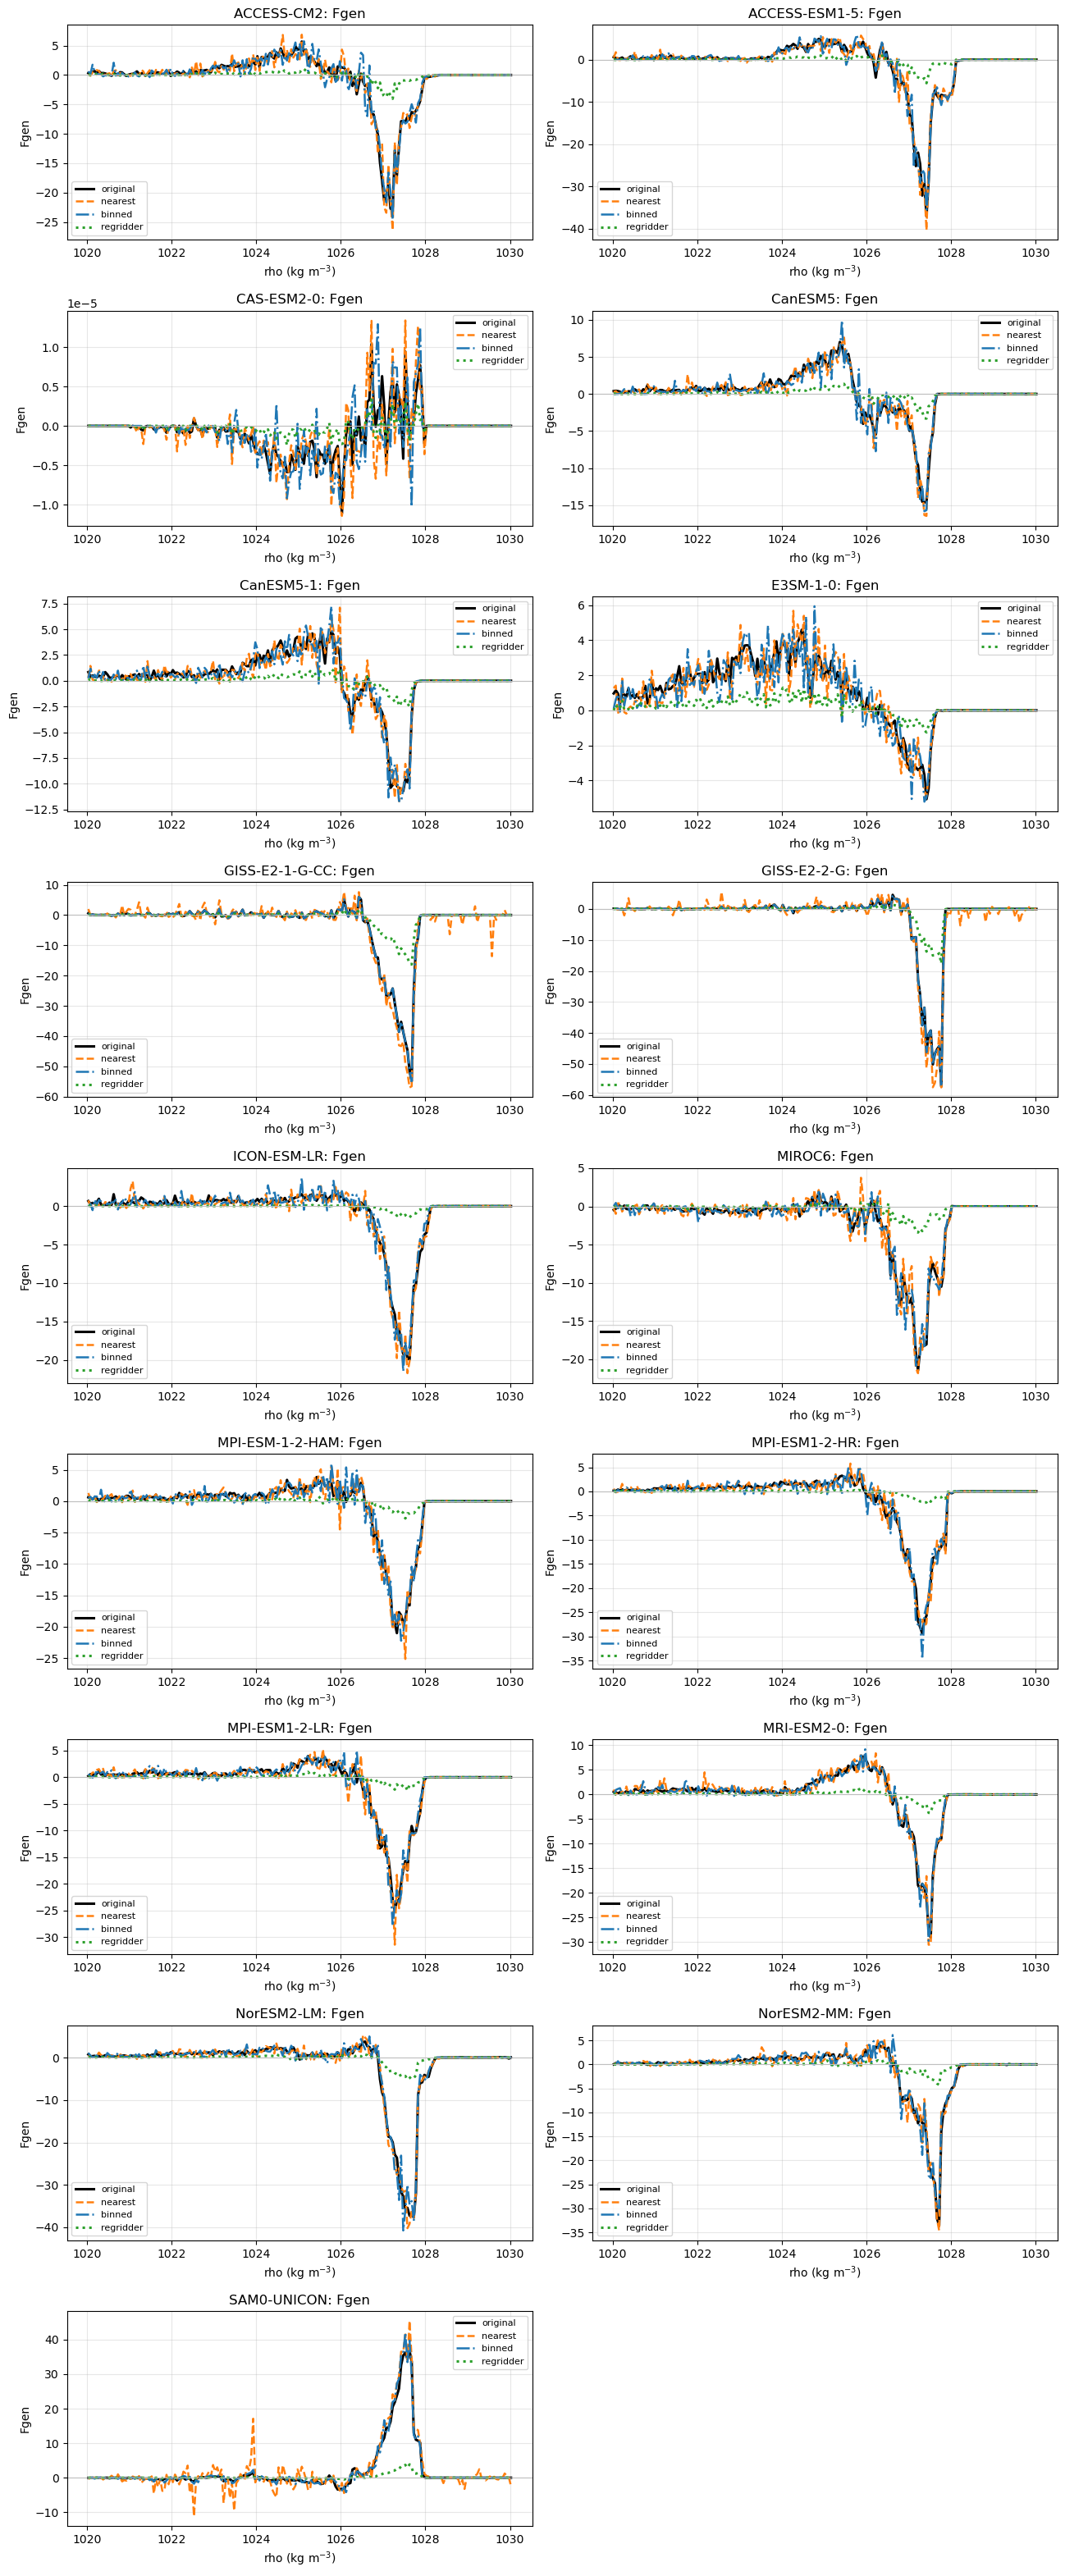

In [3]:
def subplot_grid(n_items, ncols=2, width=6.5, height=3.5):
    ncols = min(ncols, max(1, n_items))
    nrows = int(np.ceil(n_items / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(width * ncols, height * nrows), squeeze=False)
    return fig, axes.ravel()


def plot_method_profiles(column, ylabel=None, models=None):
    models = list(models or common_models)
    if not models:
        raise ValueError('No models completed for every available method')
    fig, axes = subplot_grid(len(models))
    for axis, model in zip(axes, models):
        for method in methods:
            if model not in results[method]:
                continue
            profile = results[method][model]
            profile = profile[profile['rho'] >= RHO_PLOT_MIN]
            axis.plot(profile['rho'], profile[column], label=method, **METHOD_STYLES.get(method, {}))
        axis.axhline(0, color='0.75', linewidth=0.8)
        axis.set_title(f'{model}: {column}')
        axis.set_xlabel('rho (kg m$^{-3}$)')
        axis.set_ylabel(ylabel or column)
        axis.grid(alpha=0.3)
        axis.legend(fontsize=8)
    for axis in axes[len(models):]:
        axis.axis('off')
    plt.tight_layout()
    return fig

plot_method_profiles('Fgen', 'Fgen')
plt.show()


## Heat and freshwater components

Inspect whether a changed Fgen profile comes primarily from the heat-flux or freshwater-flux component. The selected model defaults to `MIROC6` when available.


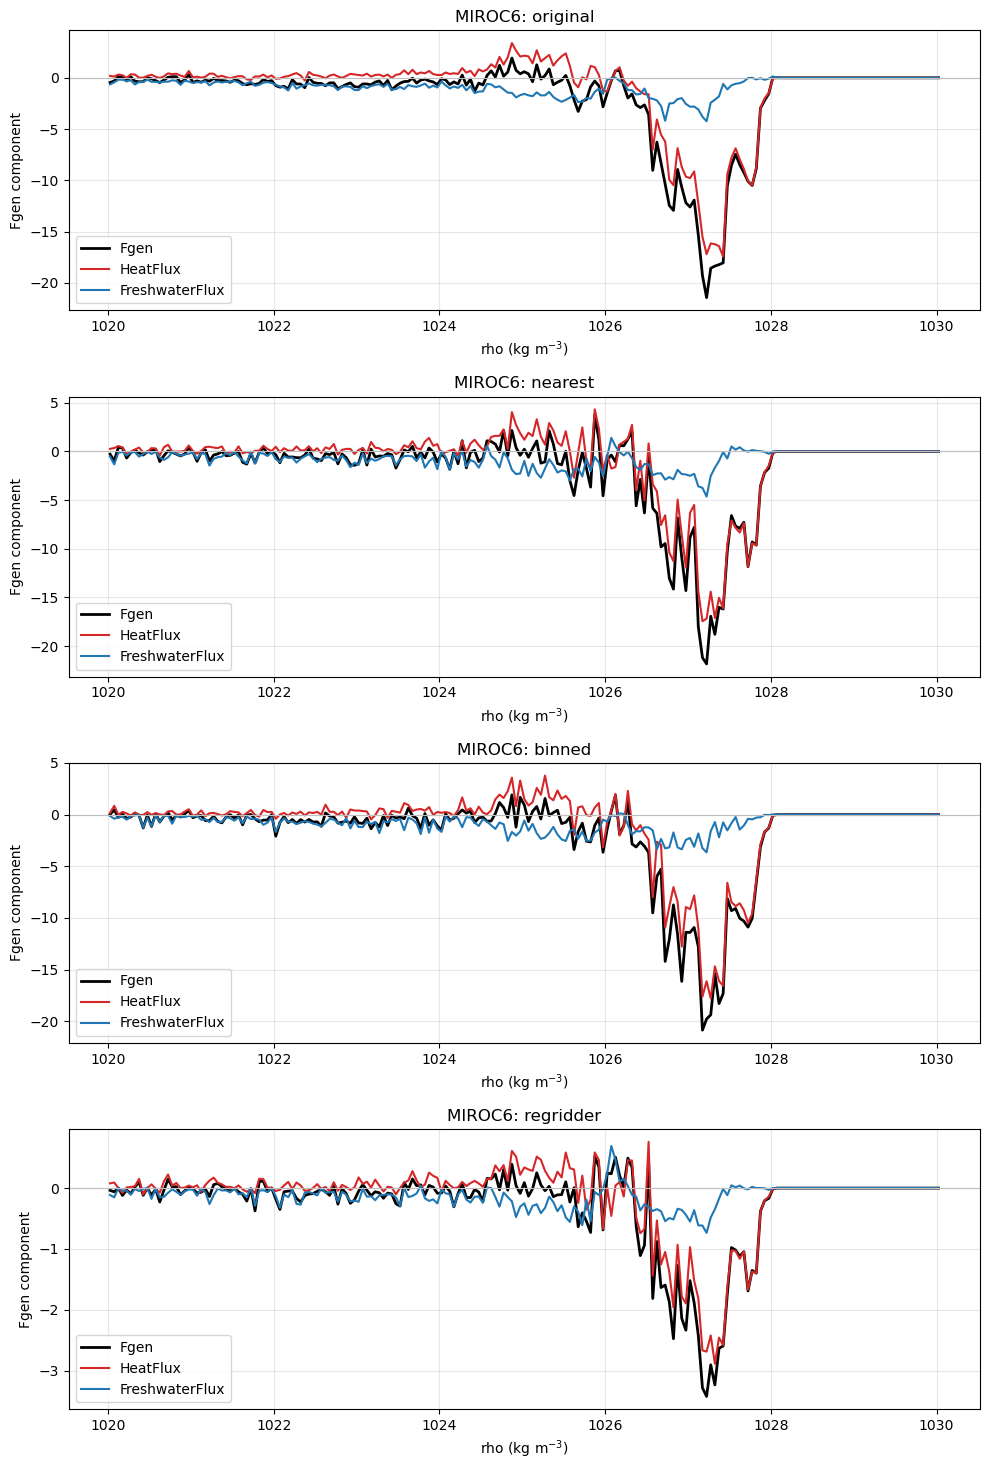

In [4]:
SELECTED_MODEL = 'MIROC6' if 'MIROC6' in all_models else (common_models[0] if common_models else all_models[0])
selected_methods = [method for method in methods if SELECTED_MODEL in results[method]]

fig, axes = plt.subplots(len(selected_methods), 1, figsize=(10, 3.7 * len(selected_methods)), squeeze=False)
for axis, method in zip(axes.ravel(), selected_methods):
    profile = results[method][SELECTED_MODEL]
    profile = profile[profile['rho'] >= RHO_PLOT_MIN]
    axis.plot(profile['rho'], profile['Fgen'], color='black', linewidth=2, label='Fgen')
    axis.plot(profile['rho'], profile['HeatFlux'], color='tab:red', label='HeatFlux')
    axis.plot(profile['rho'], profile['FreshwaterFlux'], color='tab:blue', label='FreshwaterFlux')
    axis.axhline(0, color='0.75', linewidth=0.8)
    axis.set_title(f'{SELECTED_MODEL}: {method}')
    axis.set_xlabel('rho (kg m$^{-3}$)')
    axis.set_ylabel('Fgen component')
    axis.grid(alpha=0.3)
    axis.legend()
plt.tight_layout()
plt.show()


## Evaluation metrics

The summary uses the same types of metrics as the active Fgen evaluation notebooks: minimum values and the density integral of negative values. `AreaSum_total` is included as a diagnostic; regridded `areacello` from the `regridder` method is not area-conserving.


In [5]:
def negative_integral(profile, column):
    negative_magnitude = np.clip(-profile[column].to_numpy(), 0.0, None)
    return float(np.trapz(negative_magnitude, profile['rho'].to_numpy()))


def profile_summary(model, method, profile):
    minimum_index = profile['Fgen'].idxmin()
    return {
        'model': model,
        'method': method,
        'Fgen_min': float(profile.loc[minimum_index, 'Fgen']),
        'rho_at_Fgen_min': float(profile.loc[minimum_index, 'rho']),
        'negative_Fgen_integral': negative_integral(profile, 'Fgen'),
        'negative_HeatFlux_integral': negative_integral(profile, 'HeatFlux'),
        'negative_FreshwaterFlux_integral': negative_integral(profile, 'FreshwaterFlux'),
        'AreaSum_total': float(profile['AreaSum'].sum()),
    }

summary = pd.DataFrame([
    profile_summary(model, method, profile)
    for method in methods
    for model, profile in results[method].items()
])
summary.sort_values(['model', 'method'])


,model,method,Fgen_min,rho_at_Fgen_min,negative_Fgen_integral,negative_HeatFlux_integral,negative_FreshwaterFlux_integral,AreaSum_total
36,ACCESS-CM2,binned,-24.590369,1027.225,15.190328,19.250836,0.145905,1.415913e+13
19,ACCESS-CM2,nearest,-26.386733,1027.225,15.087256,18.808419,0.268643,1.414998e+13
0,ACCESS-CM2,original,-23.072229,1027.225,15.096655,19.232652,0.111473,1.459829e+13
53,ACCESS-CM2,regridder,-4.035060,1027.225,2.309481,2.732333,0.055147,2.268965e+12
37,ACCESS-ESM1-5,binned,-35.471514,1027.425,19.603489,23.574324,0.129695,1.417169e+13
...,...,...,...,...,...,...,...,...
70,NorESM2-MM,regridder,-4.266936,1027.725,2.518874,3.255826,0.105729,2.290770e+12
52,SAM0-UNICON,binned,-4.172066,1026.125,3.637094,3.637094,0.000000,1.745072e+13
35,SAM0-UNICON,nearest,-11.141785,1022.525,8.663077,8.663077,0.000000,2.409220e+13
18,SAM0-UNICON,original,-3.670721,1026.075,3.367676,3.367676,0.000000,1.572656e+13


In [6]:
def percent_difference(value, reference):
    return np.nan if reference == 0 else 100.0 * (value - reference) / abs(reference)

comparison_rows = []
for method in methods:
    if method == 'original' or 'original' not in results:
        continue
    comparable = sorted(set(results['original']) & set(results[method]))
    for model in comparable:
        reference_profile = results['original'][model].set_index('rho')
        reference_summary = summary[(summary['model'] == model) & (summary['method'] == 'original')].iloc[0]
        aligned_profile = results[method][model].set_index('rho')
        joined = reference_profile[['Fgen']].join(
            aligned_profile[['Fgen']],
            lsuffix='_original',
            rsuffix='_aligned',
        ).dropna()
        method_summary = summary[(summary['model'] == model) & (summary['method'] == method)].iloc[0]
        difference = joined['Fgen_aligned'] - joined['Fgen_original']
        comparison_rows.append({
            'model': model,
            'method': method,
            'Fgen_RMSE': float(np.sqrt(np.mean(difference**2))),
            'Fgen_max_abs_difference': float(np.max(np.abs(difference))),
            'Fgen_min_percent_difference': percent_difference(method_summary['Fgen_min'], reference_summary['Fgen_min']),
            'negative_Fgen_integral_percent_difference': percent_difference(method_summary['negative_Fgen_integral'], reference_summary['negative_Fgen_integral']),
            'AreaSum_total_percent_difference': percent_difference(method_summary['AreaSum_total'], reference_summary['AreaSum_total']),
        })

comparison = pd.DataFrame(comparison_rows)
comparison.sort_values(['model', 'method'])


,model,method,Fgen_RMSE,Fgen_max_abs_difference,Fgen_min_percent_difference,negative_Fgen_integral_percent_difference,AreaSum_total_percent_difference
17,ACCESS-CM2,binned,9.678503e-01,5.363802e+00,-6.579947,0.620489,-3.008315
0,ACCESS-CM2,nearest,8.905496e-01,6.317299e+00,-14.365775,-0.062256,-3.070960
34,ACCESS-CM2,regridder,3.321319e+00,1.918196e+01,82.511185,-84.702032,-84.457326
18,ACCESS-ESM1-5,binned,1.077178e+00,6.570113e+00,4.236763,-3.533759,-3.015996
1,ACCESS-ESM1-5,nearest,1.010508e+00,7.323198e+00,-8.910547,-1.118221,-3.031124
35,ACCESS-ESM1-5,regridder,4.488786e+00,3.147067e+01,84.962062,-85.071184,-84.432898
19,CAS-ESM2-0,binned,2.142468e-06,1.094049e-05,7.494487,18.522051,1.699946
2,CAS-ESM2-0,nearest,1.519986e-06,6.852091e-06,-2.873581,17.734833,3.214527
36,CAS-ESM2-0,regridder,1.735711e-06,8.808017e-06,77.933975,-73.968174,-75.600759
20,CanESM5,binned,8.495485e-01,4.914344e+00,-8.106043,-1.724047,-3.272496


## Difference from original

Direct profile differences show where density classes are shifted or smoothed by grid alignment. These plots include every model that has an original result and at least one aligned result.


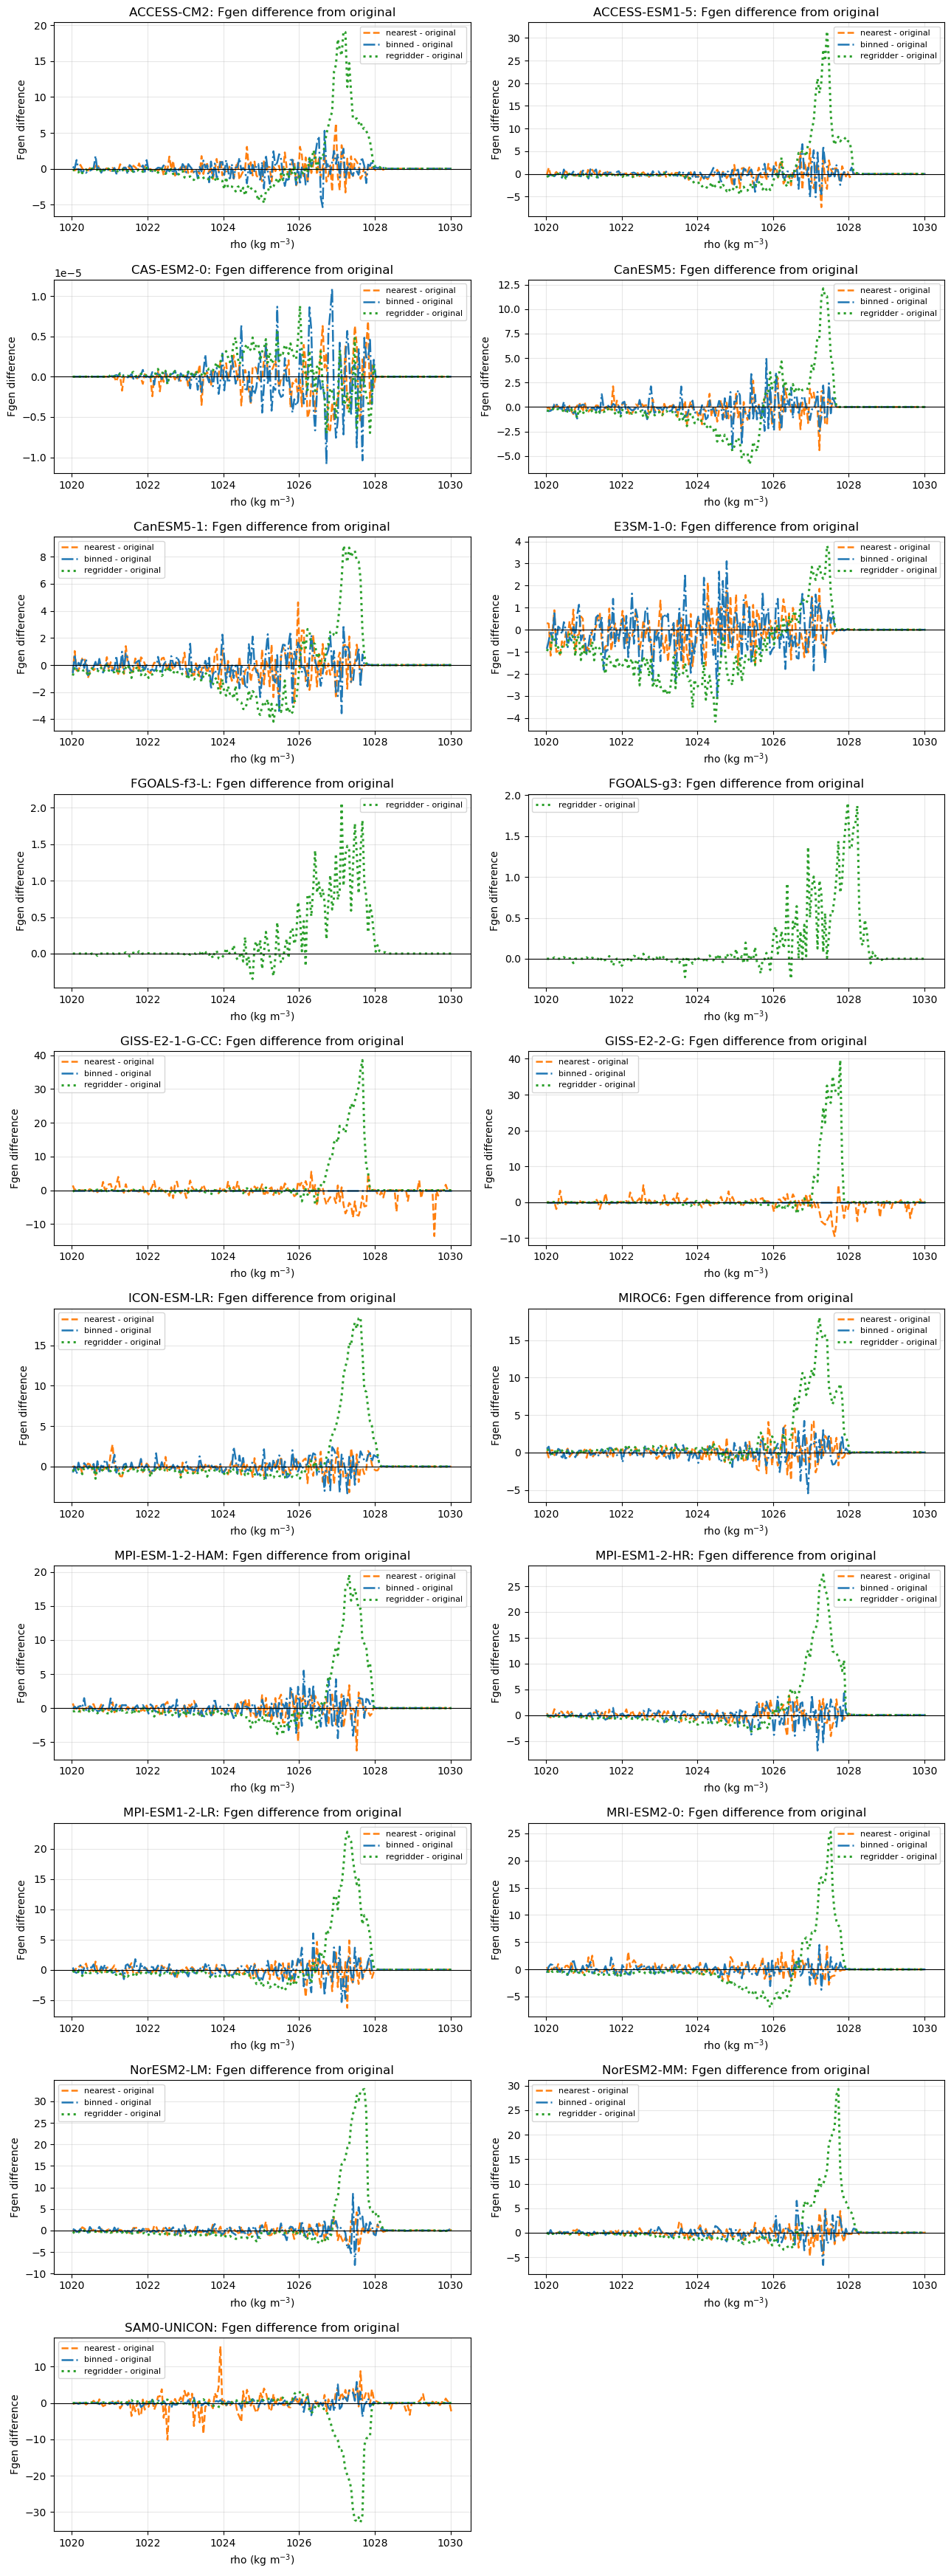

In [7]:
difference_models = sorted(
    model for model in all_models
    if 'original' in results and model in results['original'] and any(
        method != 'original' and model in results[method] for method in methods
    )
)

fig, axes = subplot_grid(len(difference_models))
for axis, model in zip(axes, difference_models):
    original = results['original'][model].set_index('rho')['Fgen']
    for method in methods:
        if method == 'original' or model not in results[method]:
            continue
        aligned = results[method][model].set_index('rho')['Fgen']
        difference = aligned - original
        difference = difference[difference.index >= RHO_PLOT_MIN]
        axis.plot(difference.index, difference.values, label=f'{method} - original', **METHOD_STYLES.get(method, {}))
    axis.axhline(0, color='black', linewidth=0.8)
    axis.set_title(f'{model}: Fgen difference from original')
    axis.set_xlabel('rho (kg m$^{-3}$)')
    axis.set_ylabel('Fgen difference')
    axis.grid(alpha=0.3)
    axis.legend(fontsize=8)
for axis in axes[len(difference_models):]:
    axis.axis('off')
plt.tight_layout()
plt.show()


## Runtime and decision notes

Use runtime together with profile error metrics. A visually smooth profile is not automatically better if it changes the integrated signal substantially.


In [8]:
if not timings.empty:
    display(timings.pivot_table(index='model', columns='method', values='seconds', aggfunc='last'))

aggregate_comparison = comparison.groupby('method').agg({
    'Fgen_RMSE': 'mean',
    'Fgen_max_abs_difference': 'mean',
    'Fgen_min_percent_difference': 'mean',
    'negative_Fgen_integral_percent_difference': 'mean',
    'AreaSum_total_percent_difference': 'mean',
}).sort_index()
display(aggregate_comparison)

if not comparison.empty:
    display(
        comparison.sort_values('Fgen_RMSE', ascending=False)
        .groupby('method')
        .head(5)
        .sort_values(['method', 'Fgen_RMSE'], ascending=[True, False])
    )


method,binned,nearest,original,regridder
model,,,,
ACCESS-CM2,0.063154,1.098246,0.206484,1.727255
ACCESS-ESM1-5,0.064585,1.076784,0.152716,0.709908
CAS-ESM2-0,0.054319,0.793408,0.031838,0.700181
CanESM5,0.061562,1.111164,0.037350,0.706191
CanESM5-1,0.062881,1.010439,0.037632,0.839977
E3SM-1-0,0.049096,0.782848,0.030069,0.572237
FGOALS-f3-L,NaN,NaN,0.090024,0.759381
FGOALS-g3,NaN,NaN,0.026473,0.652389
GISS-E2-1-G-CC,0.058090,0.359604,0.018915,0.426258


,Fgen_RMSE,Fgen_max_abs_difference,Fgen_min_percent_difference,negative_Fgen_integral_percent_difference,AreaSum_total_percent_difference
method,,,,,
binned,0.749181,4.480196,-4.031405,1.860140,-1.592701
nearest,0.959330,6.051754,-18.693089,14.723377,5.966225
regridder,3.336686,20.226949,76.429507,-77.562903,-75.196585


,model,method,Fgen_RMSE,Fgen_max_abs_difference,Fgen_min_percent_difference,negative_Fgen_integral_percent_difference,AreaSum_total_percent_difference
18,ACCESS-ESM1-5,binned,1.077178,6.570113,4.236763,-3.533759,-3.015996
31,NorESM2-LM,binned,1.074645,8.528492,-8.225371,-1.019036,-2.684326
28,MPI-ESM1-2-HR,binned,1.071018,6.879919,-17.981765,0.333429,-3.580577
29,MPI-ESM1-2-LR,binned,1.016892,5.997085,-11.095571,1.482951,-3.530688
27,MPI-ESM-1-2-HAM,binned,1.015068,5.499861,-5.793116,1.937349,-3.538905
16,SAM0-UNICON,nearest,2.022340,15.620622,-203.531263,157.241990,53.194378
6,GISS-E2-1-G-CC,nearest,1.919519,13.602806,-3.768783,22.087200,41.221342
7,GISS-E2-2-G,nearest,1.512137,9.460501,-0.618841,22.120466,43.585363
1,ACCESS-ESM1-5,nearest,1.010508,7.323198,-8.910547,-1.118221,-3.031124
12,MPI-ESM1-2-LR,nearest,0.955160,6.298574,-25.089479,4.847387,-3.522274


## Interpretation checklist

- Prefer the method with acceptably small Fgen-profile and negative-integral differences across tested grid families.
- Check completion status before comparing means; FGOALS currently has original and `regridder` results, while nearest and binned failed their area-grid match check.
- Check component plots before attributing differences to heat or freshwater forcing.
- Expand the test window before changing the production Fgen workflow.
- Keep native-grid integration as the reference because regridding can move values between density classes.
